In [ ]:
!pip -q install kagglehub tensorflow scikit-learn matplotlib seaborn pandas pillow openpyxl

In [ ]:
# Import Libraries
import os
from pathlib import Path

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

## Dataset Download

In [ ]:
data_root = kagglehub.dataset_download("sudipde25/mri-dataset-for-detection-and-analysis")
data_root = Path(data_root)

print("Dataset downloaded to:")
print(data_root)

100%|██████████| 6.46G/6.46G [01:14<00:00, 93.6MB/s]

Extracting files...


Dataset downloaded to:
/root/.cache/kagglehub/datasets/sudipde25/mri-dataset-for-detection-and-analysis/versions/33


## Dataset Preparation

In [ ]:
# Binary classification folders
tumor_root = data_root / "NINS_Dataset" / "NINS_Dataset" / "Brain Tumor"
no_tumor_root = data_root / "NINS_Dataset" / "NINS_Dataset" / "Normal"

# Tumor type folders
tumor_type_root = data_root / "NINS_Dataset" / "NINS_Dataset"

print("Tumor folder:", tumor_root)
print("No tumor folder:", no_tumor_root)
print("Tumor type root:", tumor_type_root)

print("\nTumor images:", len(os.listdir(tumor_root)))
print("No tumor images:", len(os.listdir(no_tumor_root)))
print("Tumor type folders:", os.listdir(tumor_type_root))

Tumor folder: /root/.cache/kagglehub/datasets/sudipde25/mri-dataset-for-detection-and-analysis/versions/33/NINS_Dataset/NINS_Dataset/Brain Tumor
No tumor folder: /root/.cache/kagglehub/datasets/sudipde25/mri-dataset-for-detection-and-analysis/versions/33/NINS_Dataset/NINS_Dataset/Normal
Tumor type root: /root/.cache/kagglehub/datasets/sudipde25/mri-dataset-for-detection-and-analysis/versions/33/NINS_Dataset/NINS_Dataset

Tumor images: 76
No tumor images: 1749
Tumor type folders: ['Brain Infection with abscess', 'Cerebral Hemorrhage', 'Brain Atrophy', 'Small Vessel Diease Demyelination', 'Ischemic change  demyelinating plaque', 'demyelinating lesions', 'Left Retro-orbital Haemangioma', 'Glioma', 'Encephalomalacia with gliotic change', 'focal pachymeningitis', 'Obstructive Hydrocephalus', 'Brain tumor (Dermoid cyst craniopharyngioma)', 'Malformation (Chiari I)', 'Stroke(infarct)', 'small meningioma', 'Brain Infection', 'Microvascular ischemic change', 'Brain tumor operated with ventricul

In [ ]:
# Define valid image file formats to ensure only appropriate image types are processed
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

binary_records = []

# Loop through all files in the tumour folder
for file in tumor_root.iterdir():
    # Check if the file is a valid image
    if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS:
        # Add the file path and label tumor to the list
        binary_records.append({
            "filepath": str(file),
            "label": "tumor"
        })
# Loop through all files in the no tumour folder
for file in no_tumor_root.iterdir():
    if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS:
        # Add the file path and label no_tumor to the list
        binary_records.append({
            "filepath": str(file),
            "label": "no_tumor"
        })

binary_df = pd.DataFrame(binary_records)

# Print total number of images in the dataset
print("Total binary images:", len(binary_df))
print(binary_df["label"].value_counts())
binary_df.head()

Total binary images: 1825
label
no_tumor    1749
tumor         76
Name: count, dtype: int64


,filepath,label
0,/root/.cache/kagglehub/datasets/sudipde25/mri-...,tumor
1,/root/.cache/kagglehub/datasets/sudipde25/mri-...,tumor
2,/root/.cache/kagglehub/datasets/sudipde25/mri-...,tumor
3,/root/.cache/kagglehub/datasets/sudipde25/mri-...,tumor
4,/root/.cache/kagglehub/datasets/sudipde25/mri-...,tumor


## Tumor vs No Tumor Classification

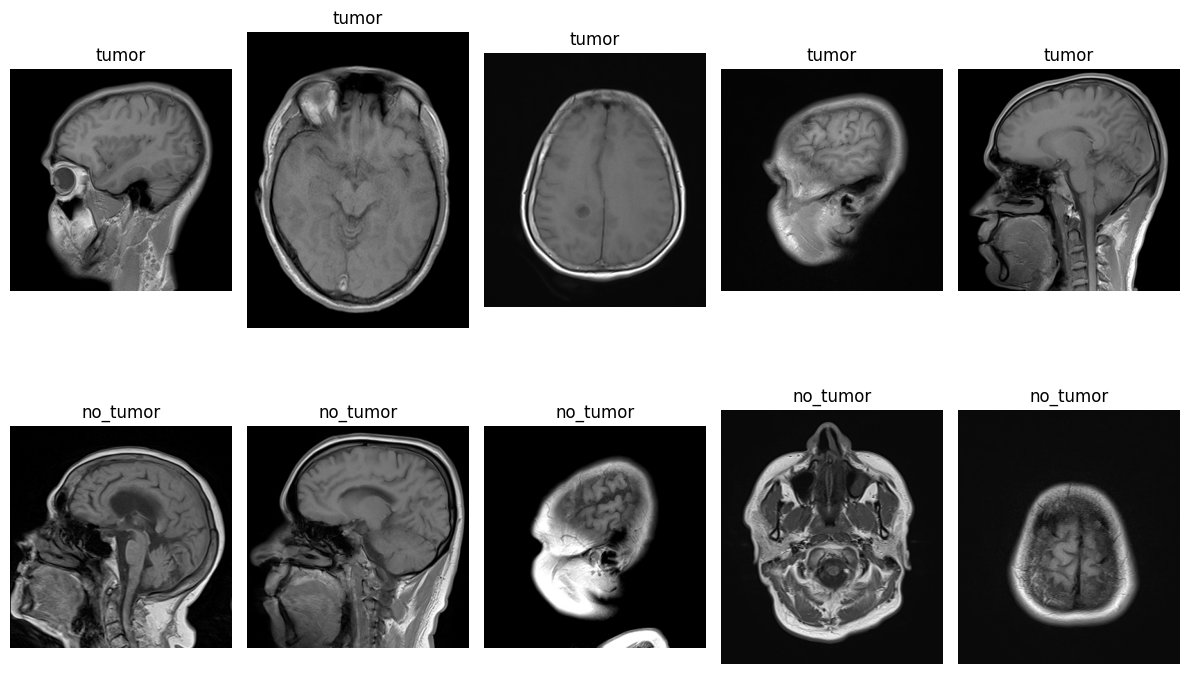

In [ ]:
# Select a small random sample of tumour and no tumour images
tumor_samples = binary_df[binary_df["label"] == "tumor"].sample(5, random_state=42)
normal_samples = binary_df[binary_df["label"] == "no_tumor"].sample(5, random_state=42)

# Combine both samples into one dataset for visualisation
sample_df = pd.concat([tumor_samples, normal_samples])

plt.figure(figsize=(12,8))

# Loop through each image
for i, (_, row) in enumerate(sample_df.iterrows()):
    img = Image.open(row["filepath"]).convert("RGB")
    # Arrange images in a 2x5 grid
    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(row["label"])
    plt.axis("off")

plt.tight_layout()
plt.show()

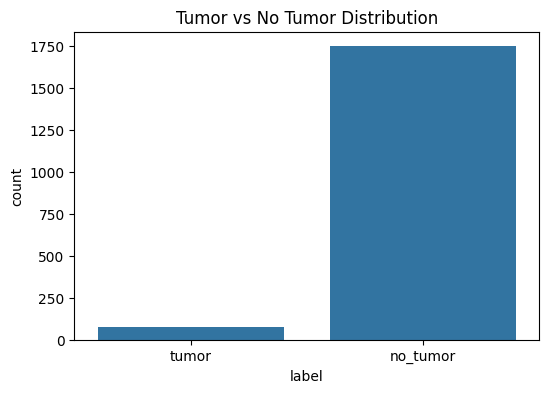

In [ ]:
# Create a figure for the class distribution plot
plt.figure(figsize=(6, 4))
sns.countplot(data=binary_df, x="label")
plt.title("Tumor vs No Tumor Distribution")
plt.show()

In [ ]:
# Split the dataset into training and temporary set
binary_train_df, binary_temp_df = train_test_split(
    binary_df,
    test_size=0.30,
    stratify=binary_df["label"],
    random_state=42
)
# Split the temporary set into validation and test
binary_val_df, binary_test_df = train_test_split(
    binary_temp_df,
    test_size=0.50,
    stratify=binary_temp_df["label"],
    random_state=42
)
# Print the size of each dataset split
print("Binary train size:", len(binary_train_df))
print("Binary validation size:", len(binary_val_df))
print("Binary test size:", len(binary_test_df))

Binary train size: 1277
Binary validation size: 274
Binary test size: 274


In [ ]:
# Create a mapping to convert text labels into numerical values
binary_label_map = {"no_tumor": 0, "tumor": 1}

binary_train_df["label_id"] = binary_train_df["label"].map(binary_label_map)
binary_val_df["label_id"] = binary_val_df["label"].map(binary_label_map)
binary_test_df["label_id"] = binary_test_df["label"].map(binary_label_map)

In [ ]:
IMG_SIZE = 160
BATCH_SIZE = 32
EPOCHS = 12
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
# Function to load and preprocess an image
def load_image(filepath, label):
    image = tf.io.read_file(filepath)
    # Decode the image and ensure it has 3 colour channels
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.efficientnet.preprocess_input(image)
    return image, label

# Define data augmentation to increase dataset diversity
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10)
])
# Function to create a TensorFlow dataset
def make_dataset(dataframe, training=False):
    filepaths = dataframe["filepath"].values
    labels = dataframe["label_id"].values

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if training:
        ds = ds.shuffle(len(dataframe), seed=42)

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=AUTOTUNE
        )

    # Batch the data and prefetch for better performance
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

In [ ]:
# Create TensorFlow datasets for training, validation and testing
binary_train_ds = make_dataset(binary_train_df, training=True)
binary_val_ds = make_dataset(binary_val_df, training=False)
binary_test_ds = make_dataset(binary_test_df, training=False)

In [ ]:
# Load EfficientNetB0 as the base model (pre-trained on ImageNet)
binary_base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
# Freeze the base model so the weights are not updated during training
binary_base_model.trainable = False

binary_inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
# Pass inputs through the pre-trained base model
x = binary_base_model(binary_inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)
binary_outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
# Create the full model
binary_model = tf.keras.Model(binary_inputs, binary_outputs)

binary_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

binary_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 5, 5, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,972 (15.47 MB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
# Define callbacks to improve training and prevent overfitting
binary_callbacks = [
    # Stop training early if validation loss does not improve
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    # Reduce learning rate if validation loss stops improving
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        verbose=1
    )
]
# Train the model using training dataset
binary_history = binary_model.fit(
    binary_train_ds,
    validation_data=binary_val_ds,
    epochs=EPOCHS,
    callbacks=binary_callbacks
)

Epoch 1/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.7032 - loss: 0.5814 - val_accuracy: 0.9562 - val_loss: 0.2325 - learning_rate: 0.0010
Epoch 2/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 30s 213ms/step - accuracy: 0.9099 - loss: 0.2912 - val_accuracy: 0.9562 - val_loss: 0.1744 - learning_rate: 0.0010
Epoch 3/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 213ms/step - accuracy: 0.9507 - loss: 0.1937 - val_accuracy: 0.9562 - val_loss: 0.1743 - learning_rate: 0.0010
Epoch 4/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 184ms/step - accuracy: 0.9514 - loss: 0.1749 - val_accuracy: 0.9562 - val_loss: 0.1715 - learning_rate: 0.0010
Epoch 5/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 204ms/step - accuracy: 0.9601 - loss: 0.1596 - val_accuracy: 0.9562 - val_loss: 0.1727 - learning_rate: 0.0010
Epoch 6/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 213ms/step - accuracy: 0.9554 - loss: 0.1566 - val_accuracy: 0.9562 - val_loss: 0.1706 - learning_rate: 0.0010
Epoch 7/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 182ms/step - accuracy: 0.9577 - loss: 0.1423 - 

In [ ]:
# Evaluate the model on the test dataset
binary_test_loss, binary_test_accuracy = binary_model.evaluate(binary_test_ds)
print("Binary test loss:", round(binary_test_loss, 4))
print("Binary test accuracy:", round(binary_test_accuracy, 4))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9635 - loss: 0.1338
Binary test loss: 0.1338
Binary test accuracy: 0.9635


In [ ]:
# Get the true labels from the test dataset
binary_y_true = binary_test_df["label_id"].values
binary_y_prob = binary_model.predict(binary_test_ds).flatten()
binary_y_pred = (binary_y_prob >= 0.5).astype(int)

print(classification_report(binary_y_true, binary_y_pred, target_names=["no_tumor", "tumor"]))

9/9 ━━━━━━━━━━━━━━━━━━━━ 14s 811ms/step
              precision    recall  f1-score   support

    no_tumor       0.96      1.00      0.98       263
       tumor       1.00      0.09      0.17        11

    accuracy                           0.96       274
   macro avg       0.98      0.55      0.57       274
weighted avg       0.96      0.96      0.95       274



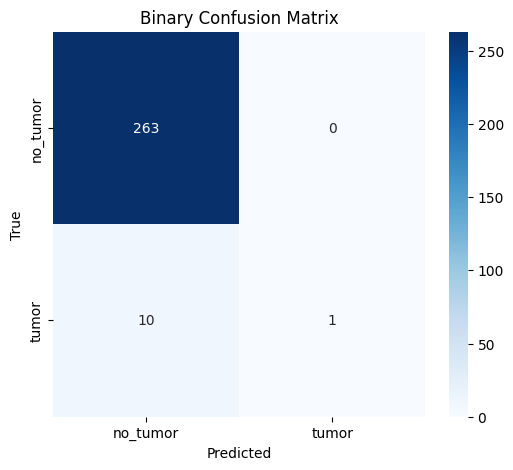

In [ ]:
# Generate confusion matrix using true labels and predicted labels
binary_cm = confusion_matrix(binary_y_true, binary_y_pred)

plt.figure(figsize=(6, 5))
# Display confusion matrix as a heatmap
sns.heatmap(
    binary_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["no_tumor", "tumor"],
    yticklabels=["no_tumor", "tumor"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Binary Confusion Matrix")
plt.show()

## Positive vs False Positive Rate

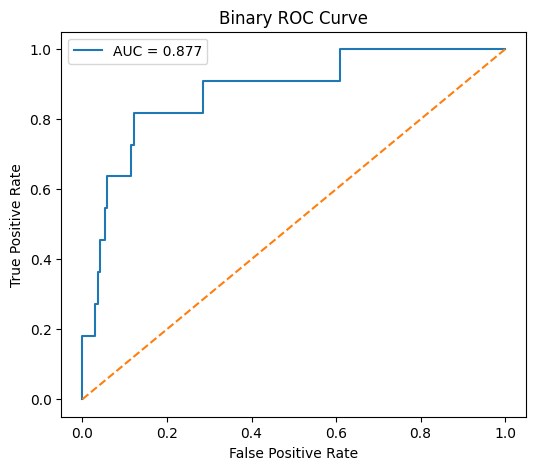

In [ ]:
# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(binary_y_true, binary_y_prob)
# Calculate Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}") # Area Under Curve
# Plot diagonal line (random model baseline)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Binary ROC Curve")
plt.legend()
plt.show()

In [ ]:
# Define tumour classes for multi-class classification
tumor_classes = ["Glioma", "meningioma"]

tumor_type_records = []
# Loop through each tumour class folder
for class_name in tumor_classes:
    folder = tumor_type_root / class_name

    for file in folder.iterdir():
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS:
            tumor_type_records.append({
                "filepath": str(file),
                "label": class_name
            })
# Convert collected data into a DataFrame
tumor_type_df = pd.DataFrame(tumor_type_records)

print("Tumor-type dataset size:", len(tumor_type_df))
# Show number of images per class (Glioma vs meningioma)
print(tumor_type_df["label"].value_counts())
tumor_type_df.head()

Tumor-type dataset size: 152
label
Glioma        76
meningioma    76
Name: count, dtype: int64


,filepath,label
0,/root/.cache/kagglehub/datasets/sudipde25/mri-...,Glioma
1,/root/.cache/kagglehub/datasets/sudipde25/mri-...,Glioma
2,/root/.cache/kagglehub/datasets/sudipde25/mri-...,Glioma
3,/root/.cache/kagglehub/datasets/sudipde25/mri-...,Glioma
4,/root/.cache/kagglehub/datasets/sudipde25/mri-...,Glioma


## Tumor Type Classification

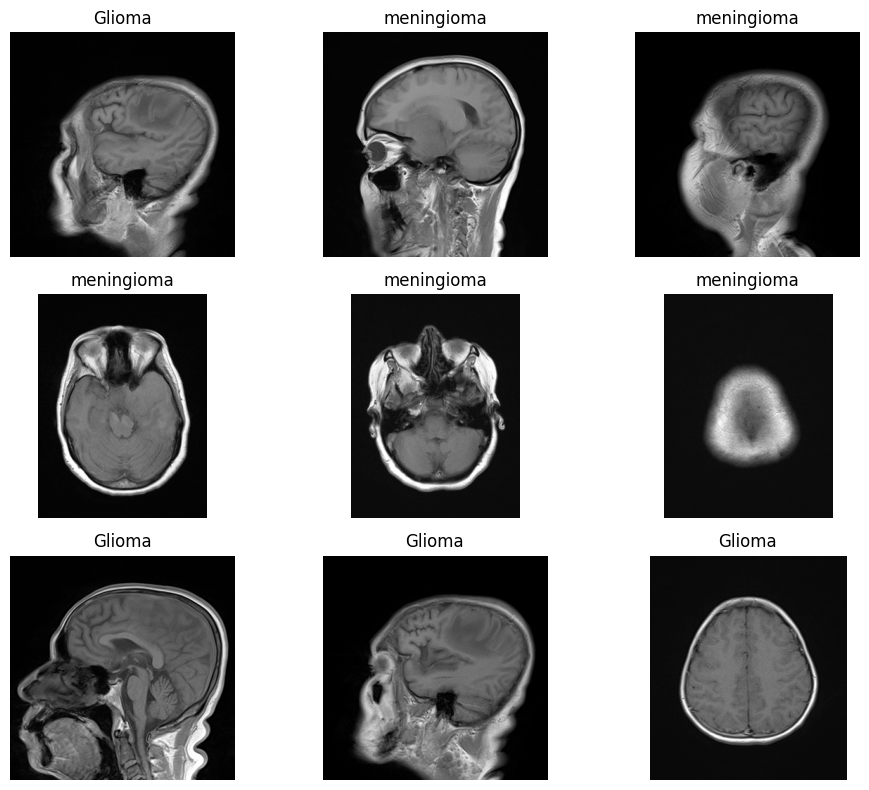

In [ ]:
# Select up to 9 random images from the tumour-type dataset
sample_df = tumor_type_df.sample(min(9, len(tumor_type_df)), random_state=42)

plt.figure(figsize=(10, 8))
# Loop through each sampled image
for i, (_, row) in enumerate(sample_df.iterrows()):
    img = Image.open(row["filepath"]).convert("RGB")
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    # Show the tumour type as the title (Glioma or meningioma)
    plt.title(row["label"])
    plt.axis("off")

plt.tight_layout()
plt.show()

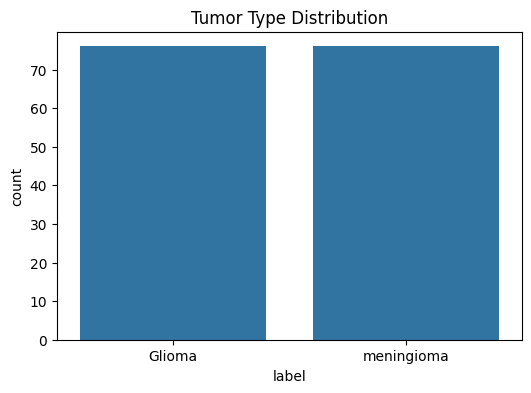

In [ ]:
# Create a figure for tumour type distribution
plt.figure(figsize=(6, 4))
# Plot the number of images in each tumour class (Glioma vs meningioma)
sns.countplot(data=tumor_type_df, x="label")
plt.title("Tumor Type Distribution")
plt.show()

In [ ]:
tumor_train_df, tumor_temp_df = train_test_split(
    tumor_type_df,
    test_size=0.30,
    stratify=tumor_type_df["label"],
    random_state=42
)

tumor_val_df, tumor_test_df = train_test_split(
    tumor_temp_df,
    test_size=0.50,
    stratify=tumor_temp_df["label"],
    random_state=42
)
# Print dataset sizes
print("Tumor-type train size:", len(tumor_train_df))
print("Tumor-type validation size:", len(tumor_val_df))
print("Tumor-type test size:", len(tumor_test_df))

Tumor-type train size: 106
Tumor-type validation size: 23
Tumor-type test size: 23


In [ ]:
# Get unique tumour labels and sort them
tumor_label_names = sorted(tumor_type_df["label"].unique())
tumor_label_map = {label: i for i, label in enumerate(tumor_label_names)}

# Convert labels to numerical format for training
tumor_train_df["label_id"] = tumor_train_df["label"].map(tumor_label_map)
tumor_val_df["label_id"] = tumor_val_df["label"].map(tumor_label_map)
tumor_test_df["label_id"] = tumor_test_df["label"].map(tumor_label_map)

print("Tumor label map:", tumor_label_map)

Tumor label map: {'Glioma': 0, 'meningioma': 1}


In [ ]:
tumor_train_ds = make_dataset(tumor_train_df, training=True)
tumor_val_ds = make_dataset(tumor_val_df, training=False)
tumor_test_ds = make_dataset(tumor_test_df, training=False)

In [ ]:
# Load EfficientNetB0 as the base model (pre-trained on ImageNet)
tumor_base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

tumor_base_model.trainable = False

tumor_inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = tumor_base_model(tumor_inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)
tumor_outputs = tf.keras.layers.Dense(len(tumor_label_names), activation="softmax")(x)

tumor_type_model = tf.keras.Model(tumor_inputs, tumor_outputs)

# Compile the model
tumor_type_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

tumor_type_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 5, 5, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,253 (15.48 MB)

 Trainable params: 5,122 (20.01 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
# Define callbacks to improve training and prevent overfitting
tumor_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        verbose=1
    )
]
# Train the tumour-type classification model
tumor_history = tumor_type_model.fit(
    tumor_train_ds,
    validation_data=tumor_val_ds,
    epochs=EPOCHS,
    callbacks=tumor_callbacks
)

Epoch 1/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 50s 10s/step - accuracy: 0.4245 - loss: 1.3422 - val_accuracy: 0.6522 - val_loss: 0.7125 - learning_rate: 0.0010
Epoch 2/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 281ms/step - accuracy: 0.5377 - loss: 1.1116 - val_accuracy: 0.6522 - val_loss: 0.6696 - learning_rate: 0.0010
Epoch 3/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 334ms/step - accuracy: 0.5943 - loss: 0.8947 - val_accuracy: 0.7391 - val_loss: 0.6300 - learning_rate: 0.0010
Epoch 4/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - accuracy: 0.6226 - loss: 0.8283 - val_accuracy: 0.7391 - val_loss: 0.6052 - learning_rate: 0.0010
Epoch 5/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 202ms/step - accuracy: 0.7170 - loss: 0.5179 - val_accuracy: 0.7826 - val_loss: 0.5913 - learning_rate: 0.0010
Epoch 6/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step - accuracy: 0.7264 - loss: 0.5828 - val_accuracy: 0.7391 - val_loss: 0.5815 - learning_rate: 0.0010
Epoch 7/12
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - accuracy: 0.7642 - loss: 0.4777 - val_accuracy: 0

In [ ]:
# Evaluate the tumour-type model on the test dataset
tumor_test_loss, tumor_test_accuracy = tumor_type_model.evaluate(tumor_test_ds)
print("Tumor-type test loss:", round(tumor_test_loss, 4))
print("Tumor-type test accuracy:", round(tumor_test_accuracy, 4))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.6087 - loss: 0.5877
Tumor-type test loss: 0.5877
Tumor-type test accuracy: 0.6087


In [ ]:
# Get true labels from test dataset
tumor_y_true = tumor_test_df["label_id"].values
tumor_y_prob = tumor_type_model.predict(tumor_test_ds)
tumor_y_pred = np.argmax(tumor_y_prob, axis=1)
# Print classification report (precision, recall, f1-score)
print(classification_report(tumor_y_true, tumor_y_pred, target_names=tumor_label_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
              precision    recall  f1-score   support

      Glioma       0.80      0.33      0.47        12
  meningioma       0.56      0.91      0.69        11

    accuracy                           0.61        23
   macro avg       0.68      0.62      0.58        23
weighted avg       0.68      0.61      0.58        23



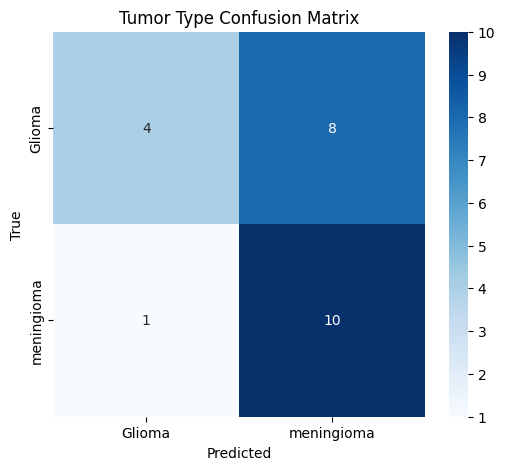

In [ ]:
# Generate confusion matrix using true and predicted labels
tumor_cm = confusion_matrix(tumor_y_true, tumor_y_pred)

plt.figure(figsize=(6, 5))
# Display confusion matrix as a heatmap
sns.heatmap(
    tumor_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=tumor_label_names,
    yticklabels=tumor_label_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Tumor Type Confusion Matrix")
plt.show()

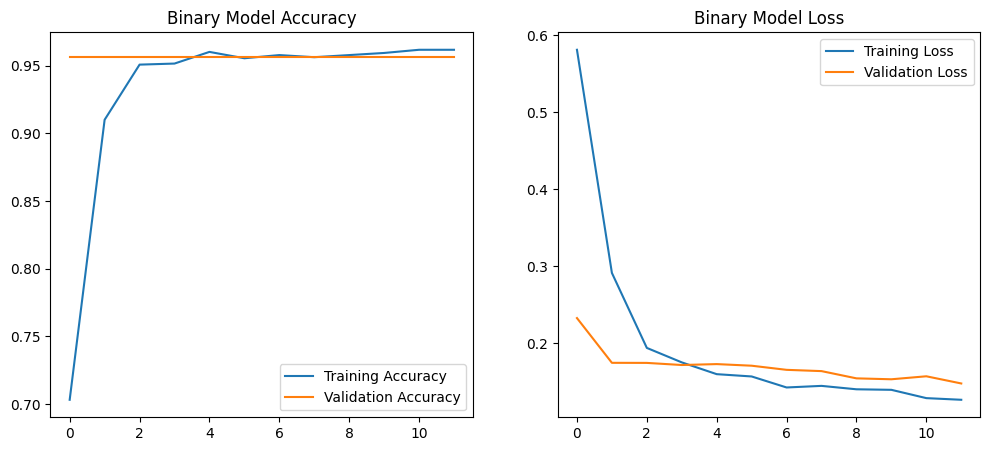

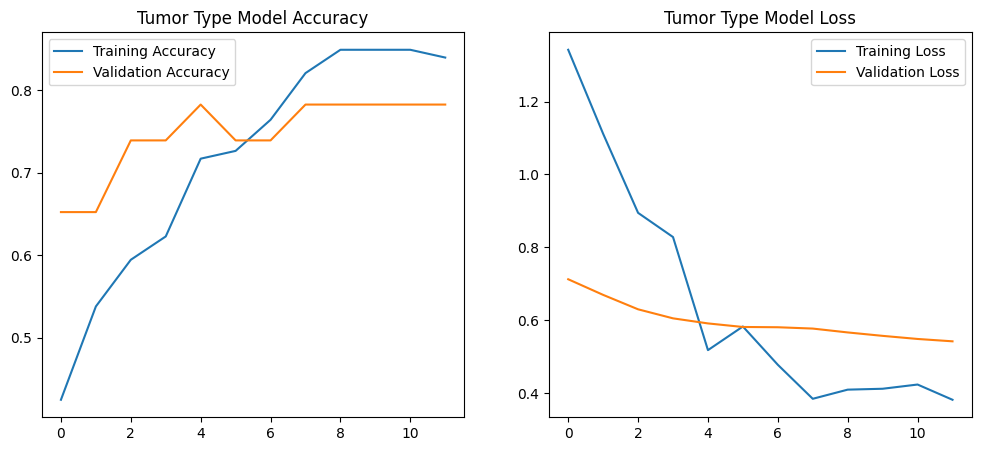

In [ ]:
# Function to plot training history (accuracy and loss)
def plot_history(history, title):
    # Extract accuracy and loss values from training history
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    # Plot training vs validation accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.legend()
    plt.title(f"{title} Accuracy")

    # Plot training vs validation loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.legend()
    plt.title(f"{title} Loss")

    plt.show()

plot_history(binary_history, "Binary Model")
plot_history(tumor_history, "Tumor Type Model")

## Two Stage Prediction System

In [ ]:
# Function to perform two-stage prediction on a single image
def two_stage_predict(image_path):
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize((IMG_SIZE, IMG_SIZE))

    # Convert image to array and prepare for model input
    img_array = np.array(img_resized).astype("float32")
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    # Stage 1
    # Predict probability of tumor
    binary_prob = binary_model.predict(img_array, verbose=0)[0][0]
    binary_label = "tumor" if binary_prob >= 0.03 else "no_tumor"

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")

    # If no tumor is detected, stop here
    if binary_label == "no_tumour":
        plt.title(f"Stage 1: no_tumour ({binary_prob:.2%} tumour probability)")
        plt.show()
        print("Final prediction: no_tumour")

    # Stage 2
    # Predict tumor type probabilities
    else:
        tumor_probs = tumor_type_model.predict(img_array, verbose=0)[0]
        tumor_index = np.argmax(tumor_probs)
        tumor_type = tumor_label_names[tumor_index]
        confidence = tumor_probs[tumor_index]

        # Display results
        plt.title(f"Stage 1: tumour | Stage 2: {tumor_type} ({confidence:.2%})")
        plt.show()
        print("Final prediction: tumor")
        print("Tumor type:", tumor_type)
        print("Tumor type confidence:", round(float(confidence), 4))

Testing no_tumor example:


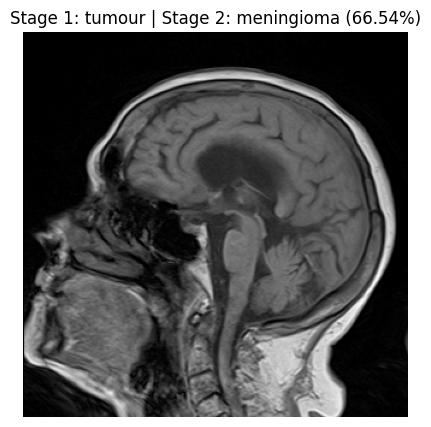

Final prediction: tumor
Tumor type: meningioma
Tumor type confidence: 0.6654

Testing tumor example:


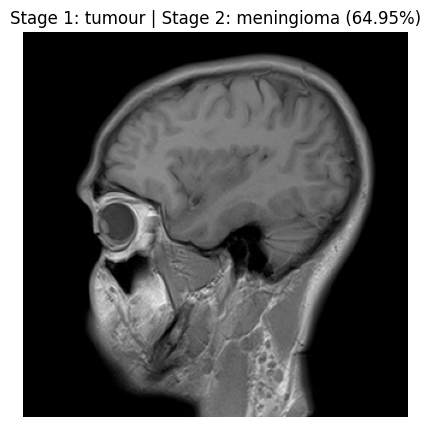

Final prediction: tumor
Tumor type: meningioma
Tumor type confidence: 0.6495


In [ ]:
# Test on one no_tumor image from the binary dataset
example_no_tumor = binary_df[binary_df["label"] == "no_tumor"].sample(1, random_state=42)["filepath"].iloc[0]
print("Testing no_tumor example:")
two_stage_predict(example_no_tumor)

# Test on one tumor image from the binary dataset
example_tumor = binary_df[binary_df["label"] == "tumor"].sample(1, random_state=42)["filepath"].iloc[0]
print("\nTesting tumor example:")
two_stage_predict(example_tumor)

In [ ]:
# Save the trained binary and tumour type classification model to file
binary_model.save("binary_tumor_detector.keras")
tumor_type_model.save("tumor_type_classifier.keras")

print("Both models saved successfully.")

Both models saved successfully.
